# Advanced Statistical Analysis and Hypothesis Testing

## Research Question

Is weekly study time associated with students' final mathematics grade?

## Dataset

UCI Student Performance Mathematics dataset.

- Predictor: `studytime`
- Outcome: `G3`
- Study-time categories: 1–4
- Final mathematics grade: 0–20

## Objective

This analysis applies normality tests, parametric and non-parametric hypothesis tests, one-way and two-way ANOVA, and Tukey HSD post-hoc analysis to investigate differences and associations in students' final mathematics grades.

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import (
    shapiro,
    kstest,
    ttest_ind,
    mannwhitneyu,
    f_oneway
)

import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [32]:
# Load the UCI Student Performance Mathematics dataset
data = pd.read_csv("../raw/student-mat.csv", sep=";")

# Display the first five rows
data.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [33]:
# Keep variables needed for the statistical analysis
analysis_data = data[["studytime", "G3"]].dropna()

# Display sample size and basic information
print("Sample size:", len(analysis_data))
print("\nStudy-time group counts:")
print(analysis_data["studytime"].value_counts().sort_index())

print("\nDescriptive statistics:")
print(analysis_data.groupby("studytime")["G3"].describe())

Sample size: 395

Study-time group counts:
studytime
1    105
2    198
3     65
4     27
Name: count, dtype: int64

Descriptive statistics:
           count       mean       std  min   25%   50%   75%   max
studytime                                                         
1          105.0  10.047619  4.956311  0.0   8.0  10.0  13.0  19.0
2          198.0  10.171717  4.217537  0.0   8.0  11.0  13.0  19.0
3           65.0  11.400000  4.639504  0.0  10.0  12.0  15.0  19.0
4           27.0  11.259259  5.281263  0.0   9.0  12.0  14.5  20.0


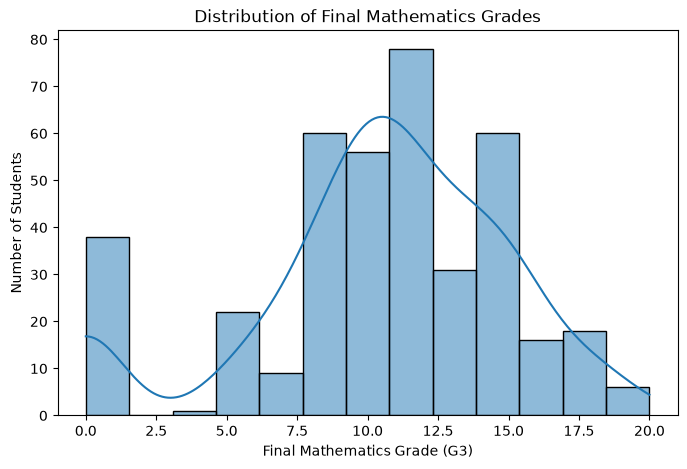

In [34]:
# Plot the distribution of final mathematics grades
plt.figure(figsize=(8, 5))
sns.histplot(analysis_data["G3"], kde=True)

plt.title("Distribution of Final Mathematics Grades")
plt.xlabel("Final Mathematics Grade (G3)")
plt.ylabel("Number of Students")
plt.show()

In [35]:
# Shapiro-Wilk normality test

statistic, p_value = shapiro(analysis_data["G3"])

print("Shapiro-Wilk Test")
print("Test statistic:", round(statistic, 4))
print("p-value:", round(p_value, 4))

if p_value < 0.05:
    print("Result: The distribution is significantly different from normal.")
else:
    print("Result: There is not enough evidence to reject normality.")

Shapiro-Wilk Test
Test statistic: 0.9287
p-value: 0.0
Result: The distribution is significantly different from normal.


In [36]:
# Kolmogorov-Smirnov normality test

# Standardize G3 before comparing with the standard normal distribution
g3_standardized = (
    analysis_data["G3"] - analysis_data["G3"].mean()
) / analysis_data["G3"].std()

ks_statistic, ks_p_value = kstest(
    g3_standardized,
    "norm"
)

print("Kolmogorov-Smirnov Test")
print("Test statistic:", round(ks_statistic, 4))
print("p-value:", ks_p_value)

if ks_p_value < 0.05:
    print("Result: The distribution is significantly different from normal.")
else:
    print("Result: There is not enough evidence to reject normality.")

Kolmogorov-Smirnov Test
Test statistic: 0.1348
p-value: 1.0168954122799307e-06
Result: The distribution is significantly different from normal.


In [37]:
# Create two study-time groups
low_study = analysis_data[
    analysis_data["studytime"].isin([1, 2])
]["G3"]

high_study = analysis_data[
    analysis_data["studytime"].isin([3, 4])
]["G3"]

# Independent two-sample t-test
t_statistic, t_p_value = ttest_ind(
    low_study,
    high_study,
    equal_var=False
)

print("Two-Sample Independent t-Test")
print("t-statistic:", round(t_statistic, 4))
print("p-value:", round(t_p_value, 4))

if t_p_value < 0.05:
    print("Result: The difference between the two groups is statistically significant.")
else:
    print("Result: The difference between the two groups is not statistically significant.")

Two-Sample Independent t-Test
t-statistic: -2.1831
p-value: 0.0307
Result: The difference between the two groups is statistically significant.


In [38]:
# Mann-Whitney U test

u_statistic, u_p_value = mannwhitneyu(
    low_study,
    high_study,
    alternative="two-sided"
)

print("Mann-Whitney U Test")
print("U statistic:", round(u_statistic, 4))
print("p-value:", round(u_p_value, 4))

if u_p_value < 0.05:
    print("Result: The difference between the two groups is statistically significant.")
else:
    print("Result: The difference between the two groups is not statistically significant.")

Mann-Whitney U Test
U statistic: 11315.5
p-value: 0.006
Result: The difference between the two groups is statistically significant.


In [39]:
# Create four study-time groups
group1 = analysis_data[analysis_data["studytime"] == 1]["G3"]
group2 = analysis_data[analysis_data["studytime"] == 2]["G3"]
group3 = analysis_data[analysis_data["studytime"] == 3]["G3"]
group4 = analysis_data[analysis_data["studytime"] == 4]["G3"]

# One-way ANOVA
anova_statistic, anova_p_value = f_oneway(
    group1,
    group2,
    group3,
    group4
)

print("One-Way ANOVA")
print("F-statistic:", round(anova_statistic, 4))
print("p-value:", round(anova_p_value, 4))

if anova_p_value < 0.05:
    print("Result: There is a statistically significant difference among the study-time groups.")
else:
    print("Result: There is no statistically significant difference among the study-time groups.")

One-Way ANOVA
F-statistic: 1.7278
p-value: 0.1607
Result: There is no statistically significant difference among the study-time groups.


In [40]:
# Tukey HSD post-hoc test

tukey_result = pairwise_tukeyhsd(
    endog=analysis_data["G3"],
    groups=analysis_data["studytime"],
    alpha=0.05
)

print(tukey_result)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     1      2   0.1241  0.996  -1.299 1.5472  False
     1      3   1.3524 0.2403 -0.5081 3.2128  False
     1      4   1.2116 0.6088  -1.332 3.7553  False
     2      3   1.2283  0.238 -0.4568 2.9134  False
     2      4   1.0875 0.6523 -1.3308 3.5059  False
     3      4  -0.1407 0.9991 -2.8397 2.5582  False
---------------------------------------------------


In [41]:
# Two-way ANOVA: study time and gender

two_way_model = ols(
    "G3 ~ C(studytime) + C(sex) + C(studytime):C(sex)",
    data=data[["studytime", "sex", "G3"]].dropna()
).fit()

two_way_anova = sm.stats.anova_lm(
    two_way_model,
    typ=2
)

print("Two-Way ANOVA")
print(two_way_anova)

Two-Way ANOVA
                          sum_sq     df         F    PR(>F)
C(studytime)          188.817520    3.0  3.071882  0.027745
C(sex)                169.130787    1.0  8.254794  0.004288
C(studytime):C(sex)    63.413567    3.0  1.031679  0.378450
Residual             7929.164353  387.0       NaN       NaN


## Two-Way ANOVA Findings

A two-way ANOVA was conducted to examine the effects of weekly study time and sex on final mathematics grade (G3).

- **Study time:** p = 0.027745. This is statistically significant at α = 0.05.
- **Sex:** p = 0.004288. This is statistically significant at α = 0.05.
- **Study time × Sex interaction:** p = 0.378450. This is not statistically significant.

### Conclusion

Weekly study time and sex are individually associated with final mathematics grade. However, there is no statistically significant evidence that the effect of study time on final grade depends on sex.

In [42]:
# 95% Confidence Interval for the difference in group means

from scipy.stats import t

n1 = len(low_study)
n2 = len(high_study)

mean_diff = low_study.mean() - high_study.mean()

s1 = low_study.var(ddof=1)
s2 = high_study.var(ddof=1)

standard_error = np.sqrt((s1 / n1) + (s2 / n2))

# Welch-Satterthwaite degrees of freedom
df = ((s1 / n1 + s2 / n2) ** 2) / (
    ((s1 / n1) ** 2 / (n1 - 1)) +
    ((s2 / n2) ** 2 / (n2 - 1))
)

critical_value = t.ppf(0.975, df)

margin_of_error = critical_value * standard_error

ci_lower = mean_diff - margin_of_error
ci_upper = mean_diff + margin_of_error

print("95% Confidence Interval")
print("Mean difference (Low Study - High Study):", round(mean_diff, 4))
print("95% CI:", (round(ci_lower, 4), round(ci_upper, 4)))

95% Confidence Interval
Mean difference (Low Study - High Study): -1.23
95% CI: (np.float64(-2.3437), np.float64(-0.1162))


## Confidence Interval Findings

A 95% confidence interval was calculated for the difference in mean final mathematics grades between the low-study-time group (studytime 1–2) and the high-study-time group (studytime 3–4).

- **Mean difference (Low − High):** -1.23
- **95% Confidence Interval:** [-2.34, -0.12]

Because the confidence interval does not include 0, there is evidence of a statistically significant difference between the two study-time groups.

The negative mean difference indicates that students in the low-study-time group had, on average, lower final mathematics grades than students in the high-study-time group.

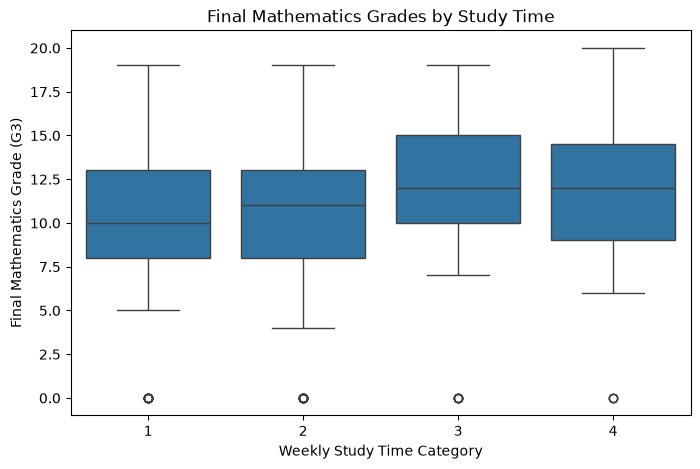

In [43]:
# Boxplot of final grades across study-time groups

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=analysis_data,
    x="studytime",
    y="G3"
)

plt.title("Final Mathematics Grades by Study Time")
plt.xlabel("Weekly Study Time Category")
plt.ylabel("Final Mathematics Grade (G3)")

plt.show()

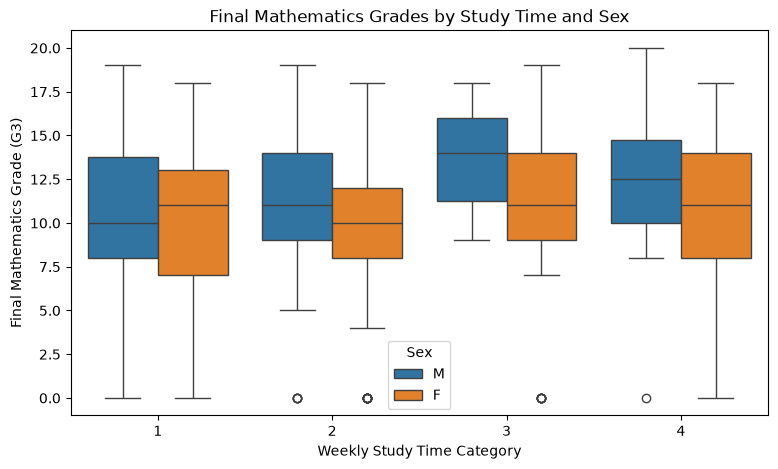

In [44]:
# Boxplot of final grades by study time and sex

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=data,
    x="studytime",
    y="G3",
    hue="sex"
)

plt.title("Final Mathematics Grades by Study Time and Sex")
plt.xlabel("Weekly Study Time Category")
plt.ylabel("Final Mathematics Grade (G3)")
plt.legend(title="Sex")

plt.show()

## Overall Hypothesis Testing Findings

### 1. Normality Tests

**Shapiro-Wilk Test**

- **H₀:** Final mathematics grades (G3) follow a normal distribution.
- **H₁:** Final mathematics grades (G3) do not follow a normal distribution.
- **Result:** p < 0.05.
- **Conclusion:** Reject H₀. The G3 distribution is not normally distributed.

**Kolmogorov-Smirnov Test**

- **H₀:** Final mathematics grades follow a normal distribution.
- **H₁:** Final mathematics grades do not follow a normal distribution.
- **Result:** p = 1.0169 × 10⁻⁶ < 0.05.
- **Conclusion:** Reject H₀. The G3 distribution significantly differs from a normal distribution.

### 2. Two-Sample t-Test

- **H₀:** The mean G3 is equal between low-study-time and high-study-time groups.
- **H₁:** The mean G3 differs between the two groups.
- **Result:** t = -2.1831, p = 0.0307.
- **Conclusion:** Reject H₀. There is a statistically significant difference between the two groups.
- **95% CI:** [-2.34, -0.12].

### 3. Mann-Whitney U Test

- **H₀:** The distributions of G3 are the same for the low-study-time and high-study-time groups.
- **H₁:** The distributions differ between the two groups.
- **Result:** U = 11315.5, p = 0.0060.
- **Conclusion:** Reject H₀. The difference is statistically significant.

### 4. One-Way ANOVA

- **H₀:** The mean G3 is equal across all four study-time groups.
- **H₁:** At least one study-time group has a different mean G3.
- **Result:** F = 1.7278, p = 0.1607.
- **Conclusion:** Fail to reject H₀. No statistically significant difference was detected across all four study-time groups.

### 5. Tukey HSD Post-Hoc Test

The Tukey HSD test found no statistically significant pairwise differences between the four study-time groups at α = 0.05. All adjusted p-values were greater than 0.05, and the confidence intervals included zero.

### 6. Two-Way ANOVA

- **Study time:** p = 0.027745 → statistically significant.
- **Sex:** p = 0.004288 → statistically significant.
- **Study time × Sex:** p = 0.378450 → not statistically significant.

### Overall Conclusion

The results provide evidence of differences in final mathematics grades between low and high study-time groups. The two-sample t-test and Mann-Whitney U test both found statistically significant differences.

However, the one-way ANOVA and Tukey HSD analysis did not find statistically significant differences among all four study-time categories.

The two-way ANOVA showed that study time and sex were individually associated with final mathematics grades, but there was no statistically significant interaction between study time and sex.